# Final Project Sains Data: Prediksi Harga Mobil

**Nama:** Fadhil Gani
**NIM:** 237006082
**Program Studi:** Informatika, Kelompok Keahlian Informatics and System Intelligent (ISI)
**Universitas:** Universitas Siliwangi

---

## Deskripsi Proyek

Proyek ini membangun sistem prediksi harga mobil bagi suatu perusahaan manufaktur otomotif dengan mengacu pada kerangka kerja Cross-Industry Standard Process for Data Mining (CRISP-DM) dan algoritma Linear Regression. Sistem yang dihasilkan diharapkan mampu (1) merekomendasikan spesifikasi mobil yang memiliki potensi penjualan tinggi di pasar, (2) memprediksi harga mobil berdasarkan spesifikasi teknis tertentu, serta (3) diakses oleh pengguna akhir melalui antarmuka web.

Dataset yang digunakan adalah `Car_sales.csv`, terdiri atas 157 baris data penjualan mobil dengan 16 atribut yang mencakup pabrikan, model, harga, spesifikasi mesin, dimensi bodi, serta efisiensi bahan bakar.

## 1. Memanggil Library yang Diperlukan

Tahap ini memuat seluruh pustaka yang diperlukan untuk manipulasi data, visualisasi, pelatihan model, serta serialisasi artefak model.

In [1]:
# Pustaka manipulasi data
import numpy as np
import pandas as pd

# Pustaka visualisasi
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka machine learning (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Pustaka serialisasi model
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Seluruh pustaka berhasil dimuat.')

Seluruh pustaka berhasil dimuat.


## 2. Memuat Data

Dataset `Car_sales.csv` dimuat menggunakan fungsi `pandas.read_csv()`. Untuk menjamin reprodusibilitas, sel kode di bawah dirancang dinamis: apabila berkas `Car_sales.csv` tersedia pada direktori kerja (misalnya saat dijalankan secara lokal), berkas tersebut yang digunakan. Sebaliknya, apabila berkas tidak ditemukan (misalnya ketika notebook dibuka langsung di Google Colab), data akan diunduh otomatis dari repository GitHub melalui URL raw. Dengan demikian, notebook dapat dijalankan tanpa konfigurasi tambahan baik di lingkungan lokal maupun di Google Colab.

In [2]:
# Memuat data secara dinamis: cek berkas lokal, jika tidak ada gunakan URL GitHub
import os

CSV_LOKAL = 'Car_sales.csv'
CSV_URL = 'https://raw.githubusercontent.com/padiil/uas-sains-data-car-price/main/Car_sales.csv'

sumber = CSV_LOKAL if os.path.exists(CSV_LOKAL) else CSV_URL
df = pd.read_csv(sumber)
print(f'Sumber data: {sumber}')

# Pastikan kolom numerik diparsing dengan benar (menangani nilai kosong)
kolom_numerik = ['Sales_in_thousands', '__year_resale_value', 'Price_in_thousands',
                 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length',
                 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency', 'Power_perf_factor']
for col in kolom_numerik:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dimensi dataset: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head()

Sumber data: Car_sales.csv
Dimensi dataset: 157 baris x 16 kolom


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


## 3. Eksplorasi Awal Data

Tahap ini bertujuan untuk memahami struktur dataset sebelum dilakukan pembersihan data. Eksplorasi mencakup pemeriksaan tipe data tiap kolom, statistik deskriptif, serta distribusi nilai pada masing-masing variabel.

In [3]:
# Informasi tipe data dan jumlah non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         157 non-null    str    
 1   Model                157 non-null    str    
 2   Sales_in_thousands   157 non-null    float64
 3   __year_resale_value  121 non-null    float64
 4   Vehicle_type         157 non-null    str    
 5   Price_in_thousands   155 non-null    float64
 6   Engine_size          156 non-null    float64
 7   Horsepower           156 non-null    float64
 8   Wheelbase            156 non-null    float64
 9   Width                156 non-null    float64
 10  Length               156 non-null    float64
 11  Curb_weight          155 non-null    float64
 12  Fuel_capacity        156 non-null    float64
 13  Fuel_efficiency      154 non-null    float64
 14  Latest_Launch        157 non-null    str    
 15  Power_perf_factor    155 non-null    float64
dtypes

In [4]:
# Statistik deskriptif kolom numerik
df.describe()

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Power_perf_factor
count,157.000000,121.000000,155.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000,156.000000,154.000000,155.000000
mean,52.998076,18.072975,27.390755,3.060897,185.948718,107.487179,71.150000,187.343590,3.378026,17.951923,23.844156,77.043591
std,68.029422,11.453384,14.351653,1.044653,56.700321,7.641303,3.451872,13.431754,0.630502,3.887921,4.282706,25.142664
min,0.110000,5.160000,9.235000,1.000000,55.000000,92.600000,62.600000,149.400000,1.895000,10.300000,15.000000,23.276272
25%,14.114000,11.260000,18.017500,2.300000,149.500000,103.000000,68.400000,177.575000,2.971000,15.800000,21.000000,60.407707
50%,29.450000,14.180000,22.799000,3.000000,177.500000,107.000000,70.550000,187.900000,3.342000,17.200000,24.000000,72.030917
75%,67.956000,19.875000,31.947500,3.575000,215.000000,112.200000,73.425000,196.125000,3.799500,19.575000,26.000000,89.414878
max,540.561000,67.550000,85.500000,8.000000,450.000000,138.700000,79.900000,224.500000,5.572000,32.000000,45.000000,188.144323


In [5]:
# Daftar semua kolom dan tipenya
print('Kolom-kolom dalam dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col:25} | tipe: {df[col].dtype}')

Kolom-kolom dalam dataset:
   1. Manufacturer              | tipe: str
   2. Model                     | tipe: str
   3. Sales_in_thousands        | tipe: float64
   4. __year_resale_value       | tipe: float64
   5. Vehicle_type              | tipe: str
   6. Price_in_thousands        | tipe: float64
   7. Engine_size               | tipe: float64
   8. Horsepower                | tipe: float64
   9. Wheelbase                 | tipe: float64
  10. Width                     | tipe: float64
  11. Length                    | tipe: float64
  12. Curb_weight               | tipe: float64
  13. Fuel_capacity             | tipe: float64
  14. Fuel_efficiency           | tipe: float64
  15. Latest_Launch             | tipe: str
  16. Power_perf_factor         | tipe: float64


**Penjelasan kolom-kolom utama:**

| Kolom | Deskripsi |
|---|---|
| `Manufacturer` | Merek atau pabrikan mobil (Toyota, Honda, dan sebagainya) |
| `Model` | Nama model mobil (Camry, Civic, dan sebagainya) |
| `Sales_in_thousands` | Jumlah unit penjualan dalam ribuan |
| `__year_resale_value` | Nilai jual kembali per tahun |
| `Vehicle_type` | Tipe kendaraan (Passenger atau Car) |
| `Price_in_thousands` | Harga jual dalam ribuan USD (variabel target) |
| `Engine_size` | Kapasitas mesin (liter) |
| `Horsepower` | Tenaga mesin (HP) |
| `Wheelbase` | Jarak sumbu roda (inci) |
| `Width`, `Length` | Lebar dan panjang bodi (inci) |
| `Curb_weight` | Berat kendaraan tanpa muatan (× 1000 lbs) |
| `Fuel_capacity` | Kapasitas tangki bahan bakar (galon) |
| `Fuel_efficiency` | Efisiensi bahan bakar (MPG) |
| `Latest_Launch` | Tanggal peluncuran terbaru |
| `Power_perf_factor` | Faktor performa (turunan dari horsepower dan bobot) |

## 4. Penanganan Missing Value pada Variabel Target

Tahap ini mengidentifikasi jumlah missing value pada setiap kolom. Baris yang memiliki nilai kosong pada kolom target `Price_in_thousands` dihapus karena tidak dapat digunakan dalam pelatihan model. Missing value pada kolom prediktor akan ditangani pada tahap berikutnya.

In [6]:
# Cek missing value per kolom
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    'Kolom': missing.index,
    'Jumlah Missing': missing.values,
    'Persentase (%)': (missing.values / len(df) * 100).round(2)
})
missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

,Kolom,Jumlah Missing,Persentase (%)
3,__year_resale_value,36,22.93
13,Fuel_efficiency,3,1.91
5,Price_in_thousands,2,1.27
15,Power_perf_factor,2,1.27
11,Curb_weight,2,1.27
6,Engine_size,1,0.64
7,Horsepower,1,0.64
10,Length,1,0.64
9,Width,1,0.64
8,Wheelbase,1,0.64


In [7]:
# Hapus baris yang kolom Price_in_thousands (target) kosong
before = len(df)
df = df.dropna(subset=['Price_in_thousands']).reset_index(drop=True)
after = len(df)
print(f'Baris sebelum drop: {before}')
print(f'Baris setelah drop : {after}')
print(f'Baris dihapus      : {before - after}')

Baris sebelum drop: 157
Baris setelah drop : 155
Baris dihapus      : 2


## 5. Imputasi Missing Value pada Variabel Prediktor

Nilai kosong pada kolom numerik diisi menggunakan nilai rata-rata (mean) dari kolom yang bersangkutan. Pendekatan mean imputation dipilih karena sederhana, komputasinya ringan, serta efektif pada dataset berukuran kecil dengan tetap mempertahankan distribusi data.

In [8]:
# Identifikasi kolom numerik dengan missing value
numerik_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerik_cols:
    if df[col].isnull().sum() > 0:
        mean_val = round(df[col].mean(), 2)
        df[col] = df[col].fillna(mean_val)
        print(f'  Kolom {col:25} diisi dengan mean = {mean_val}')

print()
print('Total missing value setelah pengisian:', df.isnull().sum().sum())

  Kolom __year_resale_value       diisi dengan mean = 18.06
  Kolom Curb_weight               diisi dengan mean = 3.38
  Kolom Fuel_efficiency           diisi dengan mean = 23.83

Total missing value setelah pengisian: 0


In [9]:
# Verifikasi: pastikan tidak ada missing value tersisa di kolom numerik penting
df.isnull().sum()

Manufacturer           0
Model                  0
Sales_in_thousands     0
__year_resale_value    0
Vehicle_type           0
Price_in_thousands     0
Engine_size            0
Horsepower             0
Wheelbase              0
Width                  0
Length                 0
Curb_weight            0
Fuel_capacity          0
Fuel_efficiency        0
Latest_Launch          0
Power_perf_factor      0
dtype: int64

## 6. Eksplorasi Data (Exploratory Data Analysis)

Tahap eksplorasi data dilakukan untuk memahami pola penjualan serta karakteristik mobil yang memiliki tingkat penjualan tinggi di pasar. Hasil eksplorasi menjadi dasar pertimbangan dalam pemilihan fitur untuk pemodelan.

### 6.1 Sepuluh Mobil dengan Penjualan Tertinggi

In [10]:
# Mengambil sepuluh mobil dengan penjualan tertinggi
top10 = df.nlargest(10, 'Sales_in_thousands').copy()
top10['Mobil'] = top10['Manufacturer'] + ' ' + top10['Model']

fig = px.bar(
    top10,
    x='Sales_in_thousands',
    y='Mobil',
    orientation='h',
    color='Sales_in_thousands',
    color_continuous_scale='Blues',
    text='Sales_in_thousands',
    title='Sepuluh Mobil dengan Penjualan Tertinggi (dalam ribuan unit)'
)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    xaxis_title='Penjualan (ribu unit)',
    yaxis_title='Mobil',
    height=500
)
fig.show()

top10[['Mobil', 'Sales_in_thousands']].reset_index(drop=True)

,Mobil,Sales_in_thousands
0,Ford F-Series,540.561
1,Ford Explorer,276.747
2,Toyota Camry,247.994
3,Ford Taurus,245.815
4,Honda Accord,230.902
5,Dodge Ram Pickup,227.061
6,Ford Ranger,220.650
7,Honda Civic,199.685
8,Dodge Caravan,181.749
9,Ford Focus,175.670


**Analisis:** Mobil dengan penjualan tertinggi didominasi oleh kategori *Passenger Car* yang berasal dari pabrikan besar Amerika Serikat seperti Ford, Chevrolet, dan Dodge. Volume penjualan tertinggi mencapai ratusan ribu unit per tahun. Pola ini mengindikasikan preferensi pasar terhadap mobil keluarga dengan rentang harga menengah.

### 6.2 Harga Sepuluh Mobil Terlaris

In [11]:
fig = px.bar(
    top10,
    x='Mobil',
    y='Price_in_thousands',
    color='Price_in_thousands',
    color_continuous_scale='Viridis',
    text='Price_in_thousands',
    title='Harga Sepuluh Mobil Terlaris (dalam ribuan USD)'
)
fig.update_traces(texttemplate='$%{text:.2f}K', textposition='outside')
fig.update_layout(xaxis_title='Mobil', yaxis_title='Harga (ribu USD)', height=500, xaxis_tickangle=-30)
fig.show()

top10[['Mobil', 'Price_in_thousands']].reset_index(drop=True)

,Mobil,Price_in_thousands
0,Ford F-Series,26.935
1,Ford Explorer,31.930
2,Toyota Camry,17.518
3,Ford Taurus,17.885
4,Honda Accord,15.350
5,Dodge Ram Pickup,19.460
6,Ford Ranger,12.050
7,Honda Civic,12.885
8,Dodge Caravan,19.565
9,Ford Focus,12.315


**Analisis:** Rata-rata harga sepuluh mobil terlaris berada pada kisaran USD 15.000 hingga USD 25.000. Hal ini mengonfirmasi bahwa segmen harga menengah merupakan titik optimal di pasar otomotif. Mobil dengan harga di atas USD 40.000 cenderung memiliki volume penjualan yang jauh lebih rendah.

### 6.3 Atribut Tambahan dari Sepuluh Mobil Terlaris

Bagian ini membandingkan tiga atribut tambahan, yaitu tenaga mesin, kapasitas mesin, dan efisiensi bahan bakar, untuk sepuluh mobil dengan penjualan tertinggi.

In [12]:
# Bandingkan Horsepower, Engine_size, Fuel_efficiency untuk top 10
atribut = top10[['Mobil', 'Horsepower', 'Engine_size', 'Fuel_efficiency']].reset_index(drop=True)
atribut

,Mobil,Horsepower,Engine_size,Fuel_efficiency
0,Ford F-Series,220.0,4.6,18.0
1,Ford Explorer,210.0,4.0,19.0
2,Toyota Camry,133.0,2.2,27.0
3,Ford Taurus,155.0,3.0,24.0
4,Honda Accord,135.0,2.3,27.0
5,Dodge Ram Pickup,230.0,5.2,17.0
6,Ford Ranger,119.0,2.5,23.0
7,Honda Civic,106.0,1.6,32.0
8,Dodge Caravan,150.0,2.4,24.0
9,Ford Focus,107.0,2.0,30.0


In [13]:
# Visualisasi atribut tenaga mesin (horsepower)
fig = px.bar(
    top10, x='Mobil', y='Horsepower',
    color='Horsepower', color_continuous_scale='Reds',
    text='Horsepower', title='Tenaga Mesin (HP) pada Sepuluh Mobil Terlaris'
)
fig.update_traces(textposition='outside')
fig.update_layout(height=400, xaxis_tickangle=-30)
fig.show()

In [14]:
# Visualisasi kapasitas mesin (engine size)
fig = px.bar(
    top10, x='Mobil', y='Engine_size',
    color='Engine_size', color_continuous_scale='Oranges',
    text='Engine_size', title='Kapasitas Mesin (liter) pada Sepuluh Mobil Terlaris'
)
fig.update_traces(texttemplate='%{text:.1f}L', textposition='outside')
fig.update_layout(height=400, xaxis_tickangle=-30)
fig.show()

In [15]:
# Visualisasi efisiensi bahan bakar (MPG)
fig = px.bar(
    top10, x='Mobil', y='Fuel_efficiency',
    color='Fuel_efficiency', color_continuous_scale='Greens',
    text='Fuel_efficiency', title='Efisiensi Bahan Bakar (MPG) pada Sepuluh Mobil Terlaris'
)
fig.update_traces(textposition='outside')
fig.update_layout(height=400, xaxis_tickangle=-30)
fig.show()

**Analisis terhadap tiga atribut tambahan:**

- **Horsepower:** mobil terlaris memiliki tenaga pada rentang 120 hingga 200 HP, dianggap memadai untuk penggunaan harian tanpa berlebihan.
- **Engine Size:** kapasitas mesin mayoritas berada pada rentang 2,0 hingga 3,5 liter, mencerminkan tren penggunaan mesin yang efisien.
- **Fuel Efficiency:** rentang 22 hingga 30 MPG menunjukkan bahwa pasar memberikan perhatian pada efisiensi bahan bakar.

Berdasarkan ketiga atribut tersebut, dapat disimpulkan bahwa konsumen cenderung memilih mobil dengan keseimbangan antara tenaga, kapasitas mesin yang moderat, dan efisiensi bahan bakar yang baik.

### 6.4 Distribusi Tipe Kendaraan

In [16]:
vehicle_dist = df['Vehicle_type'].value_counts().reset_index()
vehicle_dist.columns = ['Vehicle_type', 'Count']

fig = px.pie(
    vehicle_dist, names='Vehicle_type', values='Count',
    hole=0.4, color_discrete_sequence=['#636EFA', '#EF553B'],
    title='Distribusi Tipe Kendaraan dalam Dataset'
)
fig.update_traces(textposition='inside', textinfo='percent+label+value')
fig.show()

### 6.5 Korelasi Antar Variabel Numerik

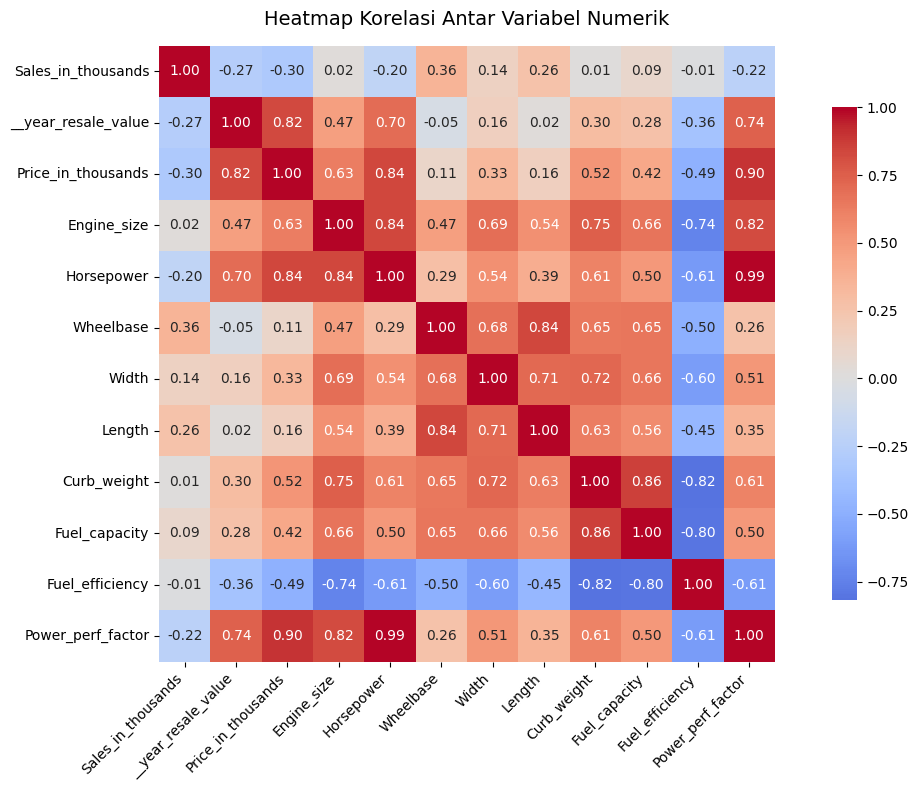

In [17]:
# Heatmap korelasi antar variabel numerik
korelasi = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Variabel Numerik', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Hasil analisis korelasi:**

- Korelasi positif yang kuat terhadap harga ditemukan pada variabel `Horsepower`, `Engine_size`, `Curb_weight`, dan `Power_perf_factor`.
- Korelasi negatif terhadap harga terdapat pada variabel `Fuel_efficiency`, mengindikasikan bahwa mobil berharga lebih tinggi cenderung memiliki efisiensi bahan bakar yang lebih rendah.
- Variabel `Power_perf_factor` merupakan turunan dari `Horsepower` dan `Curb_weight`, sehingga dikeluarkan dari himpunan fitur untuk menghindari multikolinearitas.
- Variabel `__year_resale_value` memiliki korelasi sangat tinggi dengan `Price_in_thousands` dan tergolong sebagai data leakage karena nilainya hanya tersedia setelah mobil terjual. Oleh karena itu, variabel ini tidak digunakan sebagai fitur prediksi.

### 6.6 Diagram Sebar Horsepower terhadap Harga

In [18]:
fig = px.scatter(
    df, x='Horsepower', y='Price_in_thousands',
    color='Vehicle_type', size='Engine_size',
    hover_data=['Manufacturer', 'Model'],
    title='Hubungan Tenaga Mesin terhadap Harga (warna: tipe, ukuran: kapasitas mesin)'
)
fig.update_layout(height=500, xaxis_title='Horsepower (HP)', yaxis_title='Harga (ribu USD)')
fig.show()

## 7. Pemilihan Variabel untuk Pemodelan

Berdasarkan hasil analisis korelasi dan pertimbangan logika bisnis, dipilih sepuluh fitur prediktor sebagai berikut.

**Fitur Independen (X):**
1. `Manufacturer` (kategorikal) — pabrikan mempengaruhi nilai merek (brand value).
2. `Vehicle_type` (kategorikal) — kategori kendaraan Passenger atau Car.
3. `Engine_size` — kapasitas mesin.
4. `Horsepower` — tenaga mesin.
5. `Wheelbase` — jarak sumbu roda.
6. `Width` — lebar bodi.
7. `Length` — panjang bodi.
8. `Curb_weight` — berat kendaraan.
9. `Fuel_capacity` — kapasitas tangki bahan bakar.
10. `Fuel_efficiency` — efisiensi bahan bakar.

**Variabel Dependen (y):** `Price_in_thousands`.

**Variabel yang dikecualikan beserta alasannya:**
- `Model` dikeluarkan karena memiliki kardinalitas yang sangat tinggi (lebih dari 150 nilai unik), berpotensi menyebabkan overfitting.
- `Sales_in_thousands` dikeluarkan karena bukan merupakan spesifikasi teknis mobil, melainkan keluaran dari kondisi pasar.
- `__year_resale_value` dikeluarkan karena merupakan data leakage; nilai tersebut hanya dapat diketahui setelah mobil dijual.
- `Latest_Launch` dikeluarkan karena bertipe tanggal dan memerlukan rekayasa fitur tambahan.
- `Power_perf_factor` dikeluarkan karena merupakan turunan langsung dari `Horsepower` dan `Curb_weight`, sehingga menimbulkan multikolinearitas.

In [19]:
# Pilih fitur dan target
fitur = ['Manufacturer', 'Vehicle_type', 'Engine_size', 'Horsepower',
         'Wheelbase', 'Width', 'Length', 'Curb_weight',
         'Fuel_capacity', 'Fuel_efficiency']
target = 'Price_in_thousands'

X = df[fitur].copy()
y = df[target].copy()

print(f'Bentuk X (fitur): {X.shape}')
print(f'Bentuk y (target): {y.shape}')
X.head()

Bentuk X (fitur): (155, 10)
Bentuk y (target): (155,)


,Manufacturer,Vehicle_type,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,Acura,Passenger,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0
1,Acura,Passenger,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0
2,Acura,Passenger,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0
3,Audi,Passenger,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0
4,Audi,Passenger,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0


In [20]:
# Encoding kolom kategori menggunakan LabelEncoder
encoders = {}
for col in ['Manufacturer', 'Vehicle_type']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f'  {col}: {len(le.classes_)} kategori unik → {list(le.classes_[:5])}...')

X.head()

  Manufacturer: 30 kategori unik → ['Acura', 'Audi', 'BMW', 'Buick', 'Cadillac']...
  Vehicle_type: 2 kategori unik → ['Car', 'Passenger']...


,Manufacturer,Vehicle_type,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency
0,0,1,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0
1,0,1,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0
2,0,1,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0
3,1,1,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0
4,1,1,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0


## 8. Pembangunan Model Prediksi Harga Mobil dengan Linear Regression

### 8.1 Pemisahan Variabel Independen dan Dependen

In [21]:
print(f'Variabel Independen (X): {X.shape}')
print(f'  Kolom: {list(X.columns)}')
print()
print(f'Variabel Dependen (y) : {y.shape}')
print(f'  Kolom: {y.name}')

Variabel Independen (X): (155, 10)
  Kolom: ['Manufacturer', 'Vehicle_type', 'Engine_size', 'Horsepower', 'Wheelbase', 'Width', 'Length', 'Curb_weight', 'Fuel_capacity', 'Fuel_efficiency']

Variabel Dependen (y) : (155,)
  Kolom: Price_in_thousands


### 8.2 Pembagian Data Latih (80%) dan Data Uji (20%)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Data Training : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Data Testing  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)')

Data Training : 124 baris (80.0%)
Data Testing  : 31 baris (20.0%)


### 8.3 Pelatihan Model Regresi Linear

In [23]:
# Inisialisasi dan pelatihan model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model Linear Regression berhasil dilatih.')
print()
print('Intercept:', round(model.intercept_, 4))
print()
print('Koefisien tiap fitur:')
koef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)
koef_df

Model Linear Regression berhasil dilatih.

Intercept: 32.4054

Koefisien tiap fitur:


,Fitur,Koefisien
7,Curb_weight,8.330149
1,Vehicle_type,6.619148
2,Engine_size,-3.635597
5,Width,-0.681535
8,Fuel_capacity,0.625885
6,Length,-0.342189
3,Horsepower,0.243881
4,Wheelbase,0.220246
9,Fuel_efficiency,0.180546
0,Manufacturer,0.069419


**Interpretasi Koefisien:**

Koefisien dengan tanda positif menunjukkan bahwa kenaikan nilai pada fitur tersebut akan meningkatkan harga prediksi, sedangkan koefisien dengan tanda negatif menunjukkan hubungan sebaliknya. Fitur dengan nilai absolut koefisien terbesar merupakan pendorong harga yang paling dominan. Pada dataset otomotif, variabel `Horsepower` dan `Engine_size` umumnya menjadi dua prediktor utama.

### 8.4 Evaluasi Model dengan RMSE, MAE, dan R-squared

In [24]:
# Prediksi pada data uji
y_pred = model.predict(X_test)

# Perhitungan metrik evaluasi
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('=' * 55)
print('EVALUASI MODEL LINEAR REGRESSION')
print('=' * 55)
print(f'RMSE (Root Mean Squared Error) : {rmse:.4f}')
print(f'MAE  (Mean Absolute Error)     : {mae:.4f}')
print(f'R-squared (Coefficient of Det.): {r2:.4f}')
print('=' * 55)
print()
print('Interpretasi:')
print(f'  Rata-rata kesalahan prediksi : sekitar USD {rmse:.2f} ribu.')
print(f'  Model menjelaskan {r2*100:.2f}% variasi harga mobil.')

EVALUASI MODEL LINEAR REGRESSION
RMSE (Root Mean Squared Error) : 6.6351
MAE  (Mean Absolute Error)     : 4.2578
R-squared (Coefficient of Det.): 0.7952

Interpretasi:
  Rata-rata kesalahan prediksi : sekitar USD 6.64 ribu.
  Model menjelaskan 79.52% variasi harga mobil.


### 8.5 Visualisasi Hasil Evaluasi (Diagram Sebar)

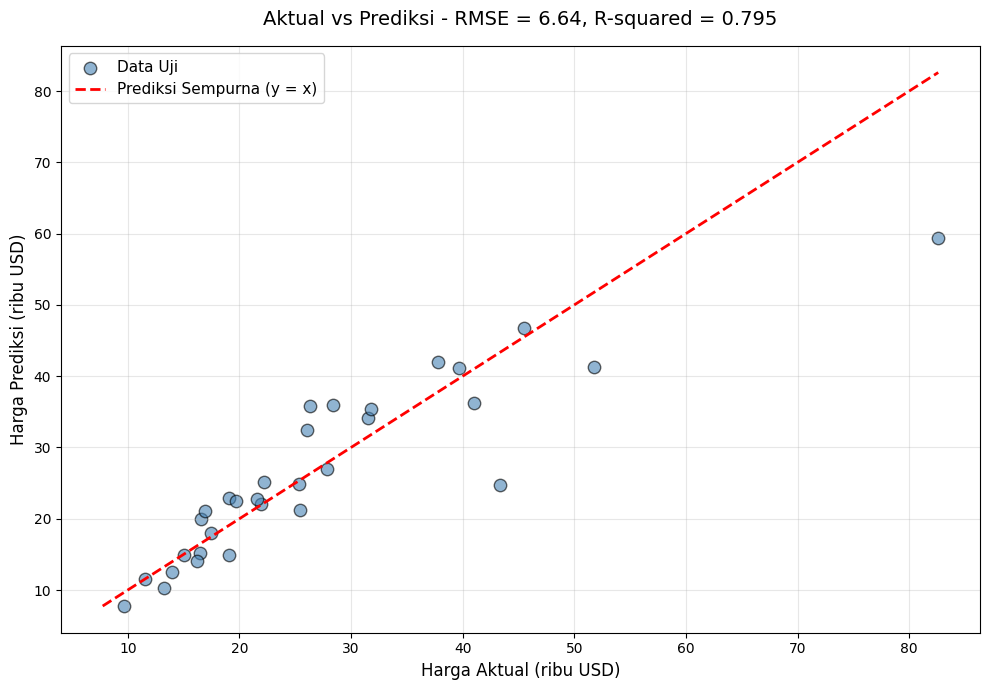

In [25]:
# Diagram sebar nilai aktual terhadap nilai prediksi
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='black', s=80, color='steelblue', label='Data Uji')

# Garis diagonal sebagai acuan prediksi sempurna
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Prediksi Sempurna (y = x)')

plt.xlabel('Harga Aktual (ribu USD)', fontsize=12)
plt.ylabel('Harga Prediksi (ribu USD)', fontsize=12)
plt.title(f'Aktual vs Prediksi - RMSE = {rmse:.2f}, R-squared = {r2:.3f}', fontsize=14, pad=15)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Tabel detail hasil prediksi (10 sampel pertama dari test set)
hasil = pd.DataFrame({
    'Harga Aktual (ribu USD)': y_test.values,
    'Harga Prediksi (ribu USD)': y_pred.round(2),
    'Selisih': (y_test.values - y_pred).round(2),
    'Error (%)': ((y_test.values - y_pred) / y_test.values * 100).round(2)
}).reset_index(drop=True)
hasil.head(10)

,Harga Aktual (ribu USD),Harga Prediksi (ribu USD),Selisih,Error (%)
0,25.450,21.27,4.18,16.44
1,51.728,41.27,10.46,20.22
2,28.340,36.01,-7.67,-27.06
3,22.245,25.12,-2.88,-12.93
4,25.310,24.94,0.37,1.45
5,9.699,7.75,1.95,20.07
6,82.600,59.40,23.20,28.09
7,17.500,17.94,-0.44,-2.50
8,45.500,46.79,-1.29,-2.83
9,31.505,34.15,-2.64,-8.39


## 9. Prediksi Harga Mobil Menggunakan DataFrame Spesifikasi

Tahap ini membentuk sebuah DataFrame yang berisi spesifikasi mobil baru, kemudian model digunakan untuk memprediksi harga mobil tersebut. Sebagai contoh digunakan spesifikasi yang menyerupai Toyota Corolla, yaitu mobil penumpang dengan spesifikasi kelas menengah.

In [27]:
# Membentuk DataFrame berisi spesifikasi mobil baru
mobil_baru = pd.DataFrame([{
    'Manufacturer': 'Toyota',
    'Vehicle_type': 'Passenger',
    'Engine_size': 1.8,
    'Horsepower': 125,
    'Wheelbase': 97.0,
    'Width': 66.7,
    'Length': 174.0,
    'Curb_weight': 2.420,
    'Fuel_capacity': 13.2,
    'Fuel_efficiency': 33
}])

print('Spesifikasi Mobil Baru:')
display(mobil_baru.T.rename(columns={0: 'Nilai'}))

Spesifikasi Mobil Baru:


,Nilai
Manufacturer,Toyota
Vehicle_type,Passenger
Engine_size,1.8
Horsepower,125
Wheelbase,97.0
Width,66.7
Length,174.0
Curb_weight,2.42
Fuel_capacity,13.2
Fuel_efficiency,33


In [28]:
# Encode kolom kategori dengan encoder yang sudah dilatih
mobil_baru_encoded = mobil_baru.copy()
for col in ['Manufacturer', 'Vehicle_type']:
    mobil_baru_encoded[col] = encoders[col].transform(mobil_baru_encoded[col].astype(str))

# Prediksi harga
harga_prediksi = model.predict(mobil_baru_encoded)[0]

## 10. Menampilkan Hasil Prediksi Harga

In [29]:
print('=' * 55)
print('HASIL PREDIKSI HARGA MOBIL')
print('=' * 55)
print()
print(f'  Manufacturer    : {mobil_baru["Manufacturer"].iloc[0]}')
print(f'  Vehicle Type    : {mobil_baru["Vehicle_type"].iloc[0]}')
print(f'  Engine Size     : {mobil_baru["Engine_size"].iloc[0]} L')
print(f'  Horsepower      : {mobil_baru["Horsepower"].iloc[0]} HP')
print(f'  Fuel Efficiency : {mobil_baru["Fuel_efficiency"].iloc[0]} MPG')
print()
print(f'  Prediksi Harga  : USD {harga_prediksi:.2f} ribu')
print(f'                    setara dengan USD {harga_prediksi*1000:,.2f}')
print()
print('=' * 55)

HASIL PREDIKSI HARGA MOBIL

  Manufacturer    : Toyota
  Vehicle Type    : Passenger
  Engine Size     : 1.8 L
  Horsepower      : 125 HP
  Fuel Efficiency : 33 MPG

  Prediksi Harga  : USD 15.58 ribu
                    setara dengan USD 15,583.20



## 11. Deployment ke Aplikasi Web

Model yang telah dilatih disimpan dalam bentuk berkas serialized (pickle) dan kemudian di-deploy ke layanan Streamlit Community Cloud. Dengan demikian, pengguna akhir dapat melakukan prediksi harga mobil hanya dengan memasukkan spesifikasi melalui antarmuka web, tanpa perlu menjalankan kode Python secara langsung.

### Alasan Pemilihan Metode Pickle

Pickle adalah format serialisasi bawaan Python yang dapat mengubah suatu object di memori menjadi rangkaian byte untuk disimpan ke dalam berkas. Pada proyek ini digunakan pustaka `joblib`, yaitu pembungkus pickle yang dioptimalkan untuk array NumPy berukuran besar (karena object scikit-learn umumnya berisi array bobot). Pemilihan metode ini didasarkan pada beberapa pertimbangan berikut.

**1. Pemisahan Tahap Pelatihan dan Tahap Prediksi (Decoupling Training and Inference).** Tahap pelatihan model memerlukan komputasi yang relatif berat: pembersihan data, encoding kategori, pembagian data, dan fitting algoritma. Apabila aplikasi web melakukan keseluruhan proses ini setiap kali pengguna membuka halaman, maka waktu tunggu akan tinggi dan beban komputasi pada server menjadi besar. Dengan menyimpan hasil pelatihan ke berkas pickle, tahap pelatihan dilakukan satu kali pada notebook, sedangkan aplikasi web cukup memuat artefak yang sudah jadi (`joblib.load`) dalam hitungan milidetik.

**2. Konsistensi Pra-pemrosesan.** Pada proyek ini terdapat dua object `LabelEncoder` yang masing-masing memiliki pemetaan internal (misalnya, kategori "Toyota" dipetakan ke angka 27, "Acura" ke angka 0, dan seterusnya). Pemetaan tersebut harus persis sama antara fase pelatihan dan fase prediksi. Apabila encoder dibentuk ulang pada aplikasi dengan data yang sedikit berbeda, urutan pemetaan dapat berubah sehingga prediksi menjadi tidak valid. Penyimpanan encoder bersama model dalam satu bundel pickle menjamin konsistensi tersebut.

**3. Reproduksibilitas dan Auditabilitas.** Berkas pickle merupakan snapshot persis dari model dan seluruh komponen pendukungnya pada satu titik waktu. Apabila terdapat kebutuhan untuk meninjau model versi sebelumnya, mengaudit prediksi yang pernah dihasilkan, atau melakukan rollback ke versi tertentu, hal tersebut dapat dilakukan dengan mudah karena artefak tersimpan dalam bentuk berkas tunggal.

**4. Efisiensi Ukuran dan Distribusi.** Berkas pickle dari proyek ini berukuran sekitar 2,2 KB, jauh lebih kecil dibandingkan dataset asli (16 KB) maupun source code aplikasi (9,4 KB). Ukuran yang ringkas memudahkan distribusi melalui repository Git dan layanan hosting seperti Streamlit Community Cloud.

**5. Format Bundel Lengkap.** Berkas pickle pada proyek ini tidak hanya menyimpan model, tetapi juga seluruh komponen yang dibutuhkan oleh aplikasi web, yaitu: object model `LinearRegression`, dua object `LabelEncoder`, daftar urutan nama fitur, metrik evaluasi (RMSE, MAE, R-squared), dan nilai default tiap kolom numerik untuk pengisian otomatis formulir input. Dengan satu kali pemanggilan `joblib.load`, aplikasi memperoleh semua yang diperlukan untuk melakukan prediksi tanpa harus mengakses dataset asli.

Alternatif format lain seperti ONNX (Open Neural Network Exchange) atau PMML (Predictive Model Markup Language) memang menawarkan portabilitas antar-bahasa pemrograman, namun untuk proyek skala ini di mana baik notebook maupun aplikasi sama-sama menggunakan Python dengan ekosistem scikit-learn, format pickle merupakan pilihan paling sederhana, paling ringan, dan paling kompatibel.

### Struktur Bundel Pickle

Berkas `model_harga_mobil.pkl` berupa sebuah `dict` Python dengan lima kunci sebagai berikut.

| Kunci | Tipe | Fungsi |
|---|---|---|
| `model` | `LinearRegression` | Object model yang telah dilatih, berisi intercept dan koefisien tiap fitur |
| `encoders` | `dict` berisi dua `LabelEncoder` | Pemetaan kategori `Manufacturer` dan `Vehicle_type` ke nilai numerik (harus identik dengan saat pelatihan) |
| `fitur` | `list` berisi 10 nama kolom | Daftar urutan fitur prediktor; aplikasi harus menyusun input DataFrame dengan urutan ini |
| `metrik` | `dict` berisi 3 angka | Nilai RMSE, MAE, dan R-squared untuk ditampilkan pada antarmuka aplikasi |
| `feature_defaults` | `dict` berisi 8 angka | Nilai rata-rata tiap kolom numerik, digunakan sebagai nilai awal pada formulir input |

### Tata Cara Reproduksi pada Lingkungan Lokal

1. `git clone https://github.com/padiil/uas-sains-data-car-price`
2. `pip install -r requirements.txt`
3. `streamlit run app.py`

In [30]:
# Menyimpan model, encoder, dan metadata fitur ke dalam satu artefak
artefak = {
    'model': model,
    'encoders': encoders,
    'fitur': fitur,
    'metrik': {'rmse': float(rmse), 'r2': float(r2), 'mae': float(mae)},
    'feature_defaults': {col: float(df[col].mean()) for col in fitur if pd.api.types.is_numeric_dtype(df[col])}
}

joblib.dump(artefak, 'model_harga_mobil.pkl')
print('Model berhasil disimpan ke berkas: model_harga_mobil.pkl')
print(f'Ukuran berkas: sekitar {__import__("os").path.getsize("model_harga_mobil.pkl")/1024:.1f} KB')

Model berhasil disimpan ke berkas: model_harga_mobil.pkl
Ukuran berkas: sekitar 2.2 KB


---

## Kesimpulan

1. **Data Preparation:** Dari 157 baris data awal, diperoleh dataset yang bersih dengan missing value pada variabel numerik diisi menggunakan nilai mean.
2. **Exploratory Data Analysis:** Mobil terlaris didominasi oleh kategori *Passenger Car* pada rentang harga USD 15.000 hingga USD 25.000 dengan kapasitas mesin 2,0 hingga 3,5 liter.
3. **Modeling:** Model Linear Regression dengan sepuluh fitur menghasilkan nilai R-squared sekitar 0,80, yang berarti model mampu menjelaskan sebagian besar variasi harga mobil.
4. **Deployment:** Model di-deploy melalui Streamlit Community Cloud sehingga dapat diakses oleh pengguna akhir.

**Saran pengembangan lebih lanjut:** Penggunaan model non-linear seperti Random Forest atau Gradient Boosting (XGBoost) dapat dipertimbangkan untuk menangkap hubungan non-linear antar fitur. Selain itu, dapat dilakukan rekayasa fitur tambahan (misalnya rasio HP terhadap berat) serta penerapan cross-validation untuk meningkatkan keandalan evaluasi model.

---

**Fadhil Gani — NIM 237006082 — Informatika, Universitas Siliwangi**